# EDA temporal — Individual Household Electric Power Consumption

## Objetivo

Este notebook tiene como objetivo analizar el comportamiento temporal del consumo eléctrico a partir del dataset limpio generado en la etapa anterior. El análisis permitirá estudiar la evolución y distribución del consumo, identificar patrones temporales, evaluar tendencia, estacionalidad y autocorrelación, y revisar el comportamiento de los valores atípicos y gaps que permanecen después de la limpieza. A diferencia del diagnóstico de calidad realizado anteriormente, esta etapa se enfoca en obtener evidencia que permita tomar decisiones para las siguientes fases del proyecto. Cada análisis será acompañado por su interpretación y por la decisión técnica que pueda afectar posteriormente la frecuencia de trabajo, el resampling, la ingeniería de características y el modelado.

## 1. Carga de datos

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Ruta raíz del proyecto
PROJECT_ROOT = Path.cwd().parent

# Dataset generado por el pipeline de limpieza
DATA_PATH = PROJECT_ROOT / "data" / "interim" / "household_power_cleaned.parquet"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "No se encontró el dataset limpio. Ejecuta primero src/cleaning/clean.py."
    )

df = pd.read_parquet(DATA_PATH)

print(f"Dataset cargado correctamente: {df.shape[0]:,} filas × {df.shape[1]} columnas")

Dataset cargado correctamente: 2,075,259 filas × 7 columnas


### Verificación inicial

Antes de comenzar el análisis exploratorio se comprobará que el dataset conserve la estructura esperada después de la limpieza: índice temporal, tipos de datos, período cubierto y valores faltantes restantes. Esta revisión no repite el diagnóstico de calidad anterior; únicamente confirma que el EDA está trabajando sobre la salida correcta del pipeline de limpieza.

In [2]:
print("Tipo de índice:", type(df.index))
print("Nombre del índice:", df.index.name)

print(f"\nFecha inicial: {df.index.min()}")
print(f"Fecha final:   {df.index.max()}")

print("\nTipos de datos:")
print(df.dtypes)

print("\nValores faltantes:")
print(df.isna().sum())

display(df.head())

Tipo de índice: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Nombre del índice: datetime

Fecha inicial: 2006-12-16 17:24:00
Fecha final:   2010-11-26 21:02:00

Tipos de datos:
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object

Valores faltantes:
Global_active_power      25691
Global_reactive_power    25691
Voltage                  25691
Global_intensity         25691
Sub_metering_1           25691
Sub_metering_2           25691
Sub_metering_3           25691
dtype: int64


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


## 2. Estadística descriptiva

Antes de analizar el comportamiento temporal de las variables, se realiza una revisión estadística del dataset limpio con el objetivo de comprender la magnitud, dispersión y distribución general de las mediciones eléctricas. Se analizarán medidas de tendencia central y dispersión como media, mediana, desviación estándar, mínimo, máximo y cuartiles. Esta revisión permitirá identificar diferencias entre las variables y servirá como punto de partida para los análisis posteriores de distribución, valores atípicos y comportamiento temporal.

In [3]:
# Estadísticos descriptivos de las variables eléctricas
descriptive_stats = df.describe().T

# Agregamos la mediana y el rango intercuartílico (IQR)
descriptive_stats["median"] = df.median()
descriptive_stats["IQR"] = (
    descriptive_stats["75%"] - descriptive_stats["25%"]
)

descriptive_stats

,count,mean,std,min,25%,50%,75%,max,median,IQR
Global_active_power,2049568.0,1.091649,1.057291,0.076,0.308,0.602,1.528,11.122,0.602,1.220
Global_reactive_power,2049568.0,0.123722,0.112724,0.000,0.048,0.100,0.194,1.390,0.100,0.146
Voltage,2049568.0,240.839735,3.240076,223.200,238.990,241.010,242.890,254.150,241.010,3.900
Global_intensity,2049568.0,4.627910,4.444385,0.200,1.400,2.600,6.400,48.400,2.600,5.000
Sub_metering_1,2049568.0,1.121865,6.152898,0.000,0.000,0.000,0.000,88.000,0.000,0.000
Sub_metering_2,2049568.0,1.298501,5.821781,0.000,0.000,0.000,1.000,80.000,0.000,1.000
Sub_metering_3,2049568.0,6.458496,8.437075,0.000,0.000,1.000,17.000,31.000,1.000,17.000


### Interpretación de los estadísticos descriptivos

Los estadísticos muestran diferencias importantes en la distribución de las variables eléctricas. `Global_active_power`, variable principal para el problema de pronóstico, presenta una media de 1.09 kW y una mediana de 0.60 kW. La diferencia entre ambas medidas sugiere que existen observaciones de consumo elevado que desplazan la media hacia valores superiores.

Un comportamiento similar se observa en `Global_intensity`, cuya media es 4.63 A frente a una mediana de 2.60 A. En contraste, `Voltage` presenta valores de media y mediana muy cercanos, alrededor de 241 V, indicando inicialmente una distribución más concentrada alrededor de su valor central.

Las variables de submedición presentan características particulares. `Sub_metering_1` tiene un valor de cero incluso en el tercer cuartil, mientras que `Sub_metering_2` presenta una mediana de cero y un tercer cuartil de 1. `Sub_metering_3` muestra una mayor dispersión, con una mediana de 1 y un tercer cuartil de 17. Esto indica que las tres submediciones poseen distribuciones diferentes y que una parte importante de sus registros se concentra en valores bajos o iguales a cero.

Los valores máximos se encuentran considerablemente alejados de los cuartiles superiores en varias variables. Sin embargo, en esta etapa no se asumirán automáticamente como errores o valores atípicos inválidos, ya que pueden representar eventos reales de consumo eléctrico.

**Decisión técnica:** conservar todas las observaciones y utilizar el análisis de distribución y el posterior estudio temporal para determinar si los valores extremos corresponden a anomalías o a patrones reales que deben ser aprendidos por el modelo.

In [4]:
# Asimetría de las variables eléctricas
skewness = df.skew().sort_values(ascending=False)

skewness.to_frame(name="skewness")

,skewness
Sub_metering_2,7.090636
Sub_metering_1,5.944700
Global_intensity,1.849114
Global_active_power,1.786255
Global_reactive_power,1.261803
Sub_metering_3,0.724659
Voltage,-0.326686


#### Asimetría

El cálculo de asimetría confirma que la mayoría de las variables eléctricas no presentan distribuciones simétricas. `Sub_metering_1` y `Sub_metering_2` muestran las mayores asimetrías positivas, con valores de 5.94 y 7.09 respectivamente, consistente con la alta concentración de observaciones en cero o valores bajos y la presencia ocasional de mediciones considerablemente mayores.

`Global_active_power` y `Global_intensity` también presentan una asimetría positiva importante, con valores cercanos a 1.8, reforzando la evidencia de una mayor concentración en niveles bajos de consumo acompañada de una cola hacia valores elevados.

En contraste, `Voltage` presenta una ligera asimetría negativa (-0.33), mientras que `Sub_metering_3` muestra una asimetría positiva más moderada.

Estos resultados justifican analizar visualmente las distribuciones antes de considerar cualquier tratamiento de valores extremos. La asimetría por sí sola no constituye evidencia suficiente para eliminar o transformar observaciones, especialmente porque los picos pueden representar comportamientos reales del consumo eléctrico.

## 3. Distribución de las variables

Una vez analizadas las principales medidas estadísticas, se estudia visualmente la distribución de las variables eléctricas. El objetivo es complementar los resultados anteriores y observar la concentración de los datos, la asimetría y la presencia de valores elevados que podrían corresponder a comportamientos poco frecuentes del consumo.

Debido a las diferencias de escala entre las variables, cada distribución se representa de forma independiente para evitar comparaciones visuales engañosas.

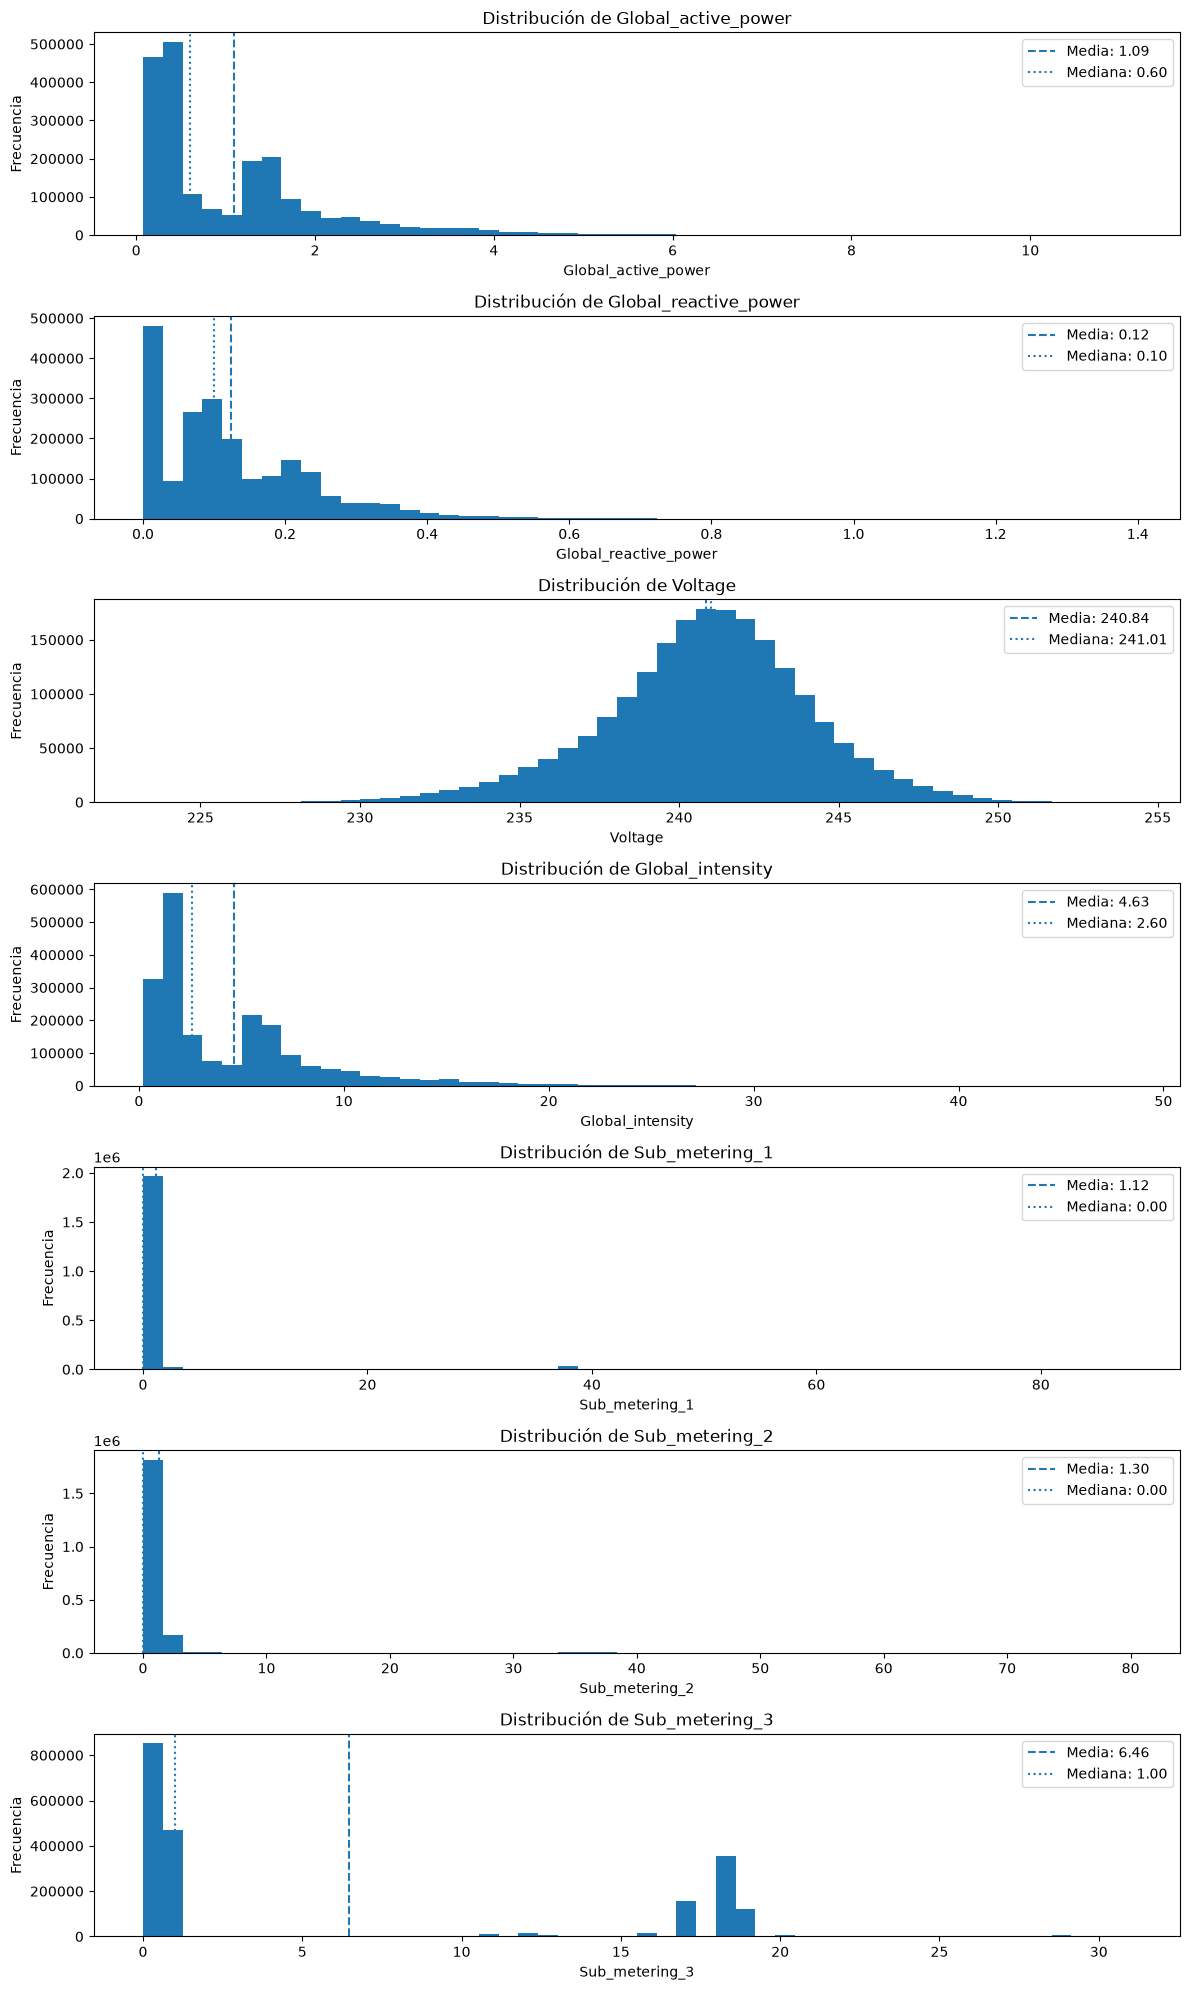

In [5]:
# Histogramas de las variables eléctricas
numeric_columns = df.columns

fig, axes = plt.subplots(
    nrows=len(numeric_columns),
    ncols=1,
    figsize=(12, 20)
)

for ax, column in zip(axes, numeric_columns):
    data = df[column].dropna()

    ax.hist(data, bins=50)
    ax.axvline(
        data.mean(),
        linestyle="--",
        label=f"Media: {data.mean():.2f}"
    )
    ax.axvline(
        data.median(),
        linestyle=":",
        label=f"Mediana: {data.median():.2f}"
    )

    ax.set_title(f"Distribución de {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Frecuencia")
    ax.legend()

plt.tight_layout()
plt.show()

### Interpretación de las distribuciones

Las distribuciones confirman visualmente las diferencias identificadas mediante los estadísticos descriptivos. `Global_active_power` y `Global_intensity` presentan una clara asimetría positiva, con una alta concentración de observaciones en niveles bajos y una cola que se extiende hacia consumos considerablemente mayores. La separación entre sus medias y medianas es consistente con este comportamiento.

`Global_reactive_power` también presenta una distribución asimétrica hacia valores altos, aunque menos pronunciada. En contraste, `Voltage` muestra una distribución mucho más concentrada alrededor de 241 V, con media y mediana prácticamente coincidentes, siendo la variable con comportamiento más cercano a una distribución simétrica.

Las variables `Sub_metering_1` y `Sub_metering_2` presentan una fuerte concentración alrededor de cero y valores elevados con mucha menor frecuencia, lo que explica sus altos coeficientes de asimetría. `Sub_metering_3` muestra un comportamiento diferente, con concentraciones tanto en valores bajos como alrededor de niveles superiores de consumo.

Los histogramas permiten concluir que las distribuciones no siguen un mismo patrón y que los valores elevados observados en varias variables forman parte de distribuciones fuertemente asimétricas. Por esta razón, no se aplicará una eliminación general de valores extremos basándose únicamente en su magnitud.

**Decisión técnica:** mantener las observaciones originales y estudiar posteriormente los valores extremos dentro de su contexto temporal. Las diferencias observadas entre las variables también deberán considerarse durante la ingeniería de características y el modelado.

## 4. Evolución temporal del consumo

Después de estudiar la distribución general de las variables, se analiza cómo evoluciona `Global_active_power` a lo largo del período disponible.

El dataset original contiene mediciones con frecuencia de un minuto, por lo que representar directamente más de dos millones de observaciones dificultaría la identificación de patrones de mediano y largo plazo. Para esta visualización exploratoria se calcula el promedio diario de potencia activa.

Esta agregación se utiliza únicamente para facilitar el análisis visual y no representa todavía una decisión sobre la frecuencia que se utilizará posteriormente para el entrenamiento del modelo.

In [6]:
# Promedio diario de potencia activa
daily_active_power = df["Global_active_power"].resample("D").mean()

print(f"Días analizados: {daily_active_power.shape[0]:,}")
print(f"Días sin información: {daily_active_power.isna().sum():,}")

daily_active_power.describe()

Días analizados: 1,442
Días sin información: 9


count    1433.000000
mean        1.092095
std         0.420437
min         0.173818
25%         0.816776
50%         1.080732
75%         1.323926
max         3.314851
Name: Global_active_power, dtype: float64

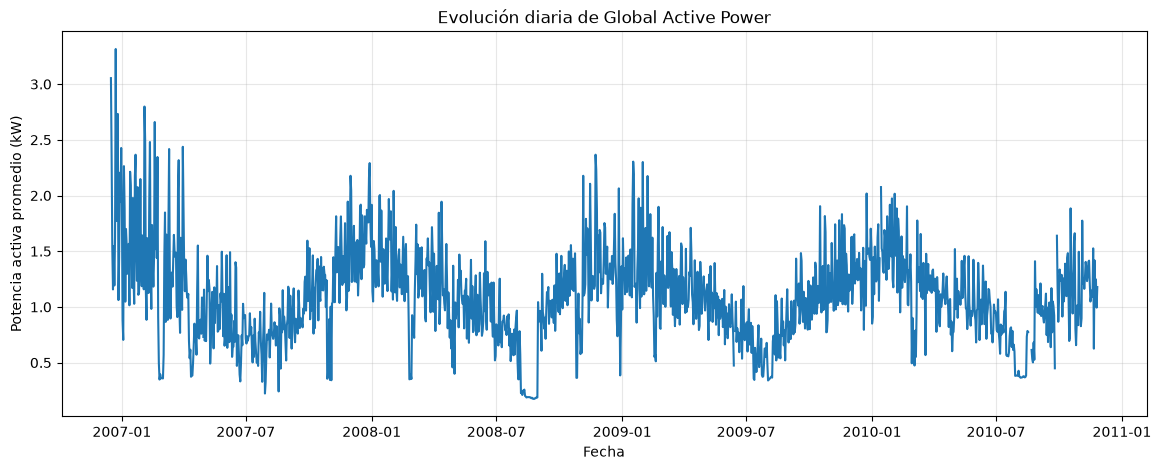

In [7]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily_active_power.index,
    daily_active_power
)

plt.title("Evolución diaria de Global Active Power")
plt.xlabel("Fecha")
plt.ylabel("Potencia activa promedio (kW)")
plt.grid(alpha=0.3)

plt.show()

### Interpretación de la evolución temporal

La serie diaria muestra que el consumo eléctrico no permanece constante a lo largo del período analizado. Se observan variaciones importantes entre días y cambios en el nivel de consumo a lo largo de los años. Visualmente aparece un comportamiento recurrente: los niveles de consumo tienden a aumentar alrededor del cierre e inicio de algunos años y a disminuir aproximadamente hacia la mitad del año. Este patrón sugiere la posible existencia de un componente estacional anual. Sin embargo, esta observación se considera únicamente evidencia exploratoria y deberá comprobarse posteriormente mediante el análisis de estacionalidad y autocorrelación.

La agregación diaria también reduce considerablemente la asimetría observada en los datos por minuto. Mientras que a nivel minuto la media de `Global_active_power` fue aproximadamente 1.09 kW y la mediana 0.60 kW, a nivel diario ambas medidas son cercanas a 1.09 kW. Esto muestra que los picos de corta duración pierden influencia al resumir el consumo mediante promedios diarios. También se observan días con consumos considerablemente superiores o inferiores al comportamiento habitual. Estos valores no serán clasificados todavía como anomalías, ya que es necesario estudiar su contexto temporal antes de determinar si corresponden a errores o a variaciones reales del consumo. Los 9 días completamente sin información se mantienen sin imputar, respetando la decisión tomada durante la etapa de limpieza de no reconstruir artificialmente gaps temporales largos.

**Decisión técnica:** la agregación diaria resulta útil para estudiar patrones de mediano y largo plazo, pero todavía no se establece como frecuencia definitiva para el modelado. La posible estacionalidad observada deberá comprobarse mediante análisis temporales posteriores antes de utilizarla para la ingeniería de características.

## 5. Patrones temporales del consumo

Después de analizar la evolución general de la serie, se estudia si el consumo eléctrico presenta comportamientos diferentes según distintos componentes del tiempo.

Se analizará `Global_active_power` por hora del día, día de la semana y mes. Estas agrupaciones permiten identificar posibles ciclos intradiarios, semanales y anuales que podrían ser relevantes posteriormente para la ingeniería de características y el modelo de pronóstico. Las variables temporales utilizadas en esta sección se crean únicamente con fines exploratorios y no modifican el dataset limpio original.

In [8]:
# DataFrame auxiliar para el análisis de patrones temporales
temporal_analysis = pd.DataFrame({
    "Global_active_power": df["Global_active_power"],
    "hour": df.index.hour,
    "day_of_week": df.index.dayofweek,
    "month": df.index.month
})

temporal_analysis.head()

,Global_active_power,hour,day_of_week,month
datetime,,,,
2006-12-16 17:24:00,4.216,17,5,12
2006-12-16 17:25:00,5.360,17,5,12
2006-12-16 17:26:00,5.374,17,5,12
2006-12-16 17:27:00,5.388,17,5,12
2006-12-16 17:28:00,3.666,17,5,12


### 5.1 Patrón de consumo por hora del día

Se analiza el promedio de `Global_active_power` para cada hora del día con el objetivo de identificar ciclos intradiarios en el consumo eléctrico. Este análisis permite determinar si existen horas en las que el hogar presenta sistemáticamente mayores o menores niveles de demanda. La presencia de un patrón horario sería relevante para la etapa de Feature Engineering, ya que la hora podría utilizarse posteriormente como una característica temporal para el modelo de pronóstico.

In [9]:
# Consumo promedio por hora del día
hourly_pattern = (
    temporal_analysis
    .groupby("hour")["Global_active_power"]
    .agg(["mean", "median", "std", "count"])
)

hourly_pattern

,mean,median,std,count
hour,,,,
0,0.659434,0.366,0.717914,85491
1,0.539325,0.328,0.585604,85440
2,0.480618,0.320,0.488526,85440
3,0.444866,0.314,0.430038,85428
4,0.443847,0.312,0.425120,85320
5,0.453674,0.310,0.445886,85260
6,0.791631,0.350,0.928929,85260
7,1.502264,1.502,1.081839,85285
8,1.460969,1.410,0.949933,85320


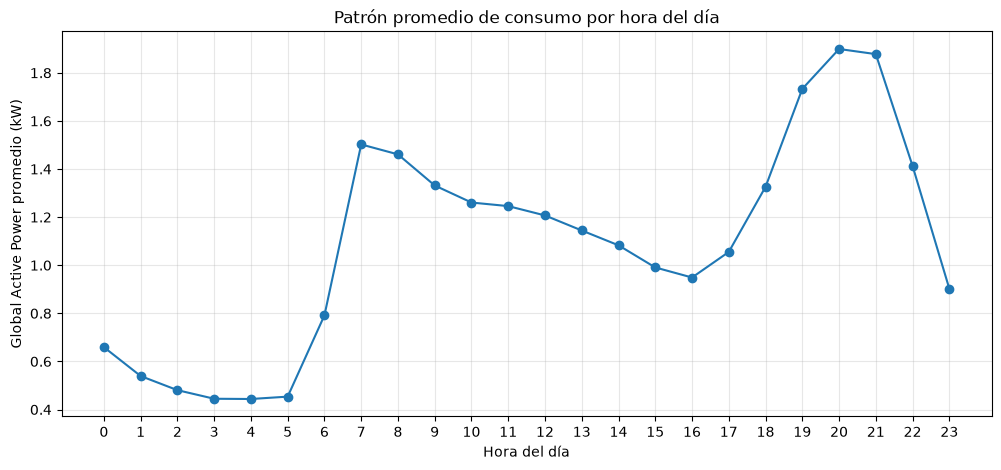

In [10]:
# Visualización del patrón promedio de consumo por hora del día
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_pattern.index,
    hourly_pattern["mean"],
    marker="o"
)

plt.xticks(range(24))
plt.title("Patrón promedio de consumo por hora del día")
plt.xlabel("Hora del día")
plt.ylabel("Global Active Power promedio (kW)")
plt.grid(alpha=0.3)

plt.show()

#### Interpretación del patrón por hora del día

El consumo eléctrico presenta un patrón intradiario claramente definido. Durante la madrugada se observan los niveles más bajos de consumo, alcanzando valores promedio cercanos a 0.44–0.48 kW entre las 2:00 y las 5:00. A partir de las 6:00 comienza un incremento importante y alrededor de las 7:00 se alcanza un primer pico cercano a 1.50 kW. Después del pico de la mañana, el consumo disminuye progresivamente durante gran parte del día, hasta alcanzar aproximadamente 0.95 kW alrededor de las 16:00. A partir de este punto comienza un segundo incremento, considerablemente más fuerte, que alcanza su máximo alrededor de las 20:00, con aproximadamente 1.90 kW. Posteriormente el consumo vuelve a disminuir durante las últimas horas del día. Este comportamiento muestra que el consumo no es independiente de la hora y aporta evidencia de un ciclo intradiario. Además, la tabla estadística mostró diferencias entre la media y la mediana en varias horas, indicando que dentro de cada franja horaria también existe variabilidad y presencia de consumos elevados que afectan el promedio.

**Decisión técnica:** la hora del día contiene información relevante para el pronóstico y deberá considerarse durante la etapa de Feature Engineering. Debido a que la hora es una variable cíclica (después de las 23:00 vuelve a las 00:00), posteriormente se evaluará su representación mediante características cíclicas en lugar de tratarla únicamente como un número entero.

### 5.2 Patrón de consumo por día de la semana

Se analiza el comportamiento de `Global_active_power` según el día de la semana para determinar si existen diferencias sistemáticas entre los distintos días. Este análisis permite identificar posibles patrones semanales y evaluar si el día de la semana puede aportar información útil posteriormente durante la ingeniería de características del modelo de pronóstico.

In [11]:
# Consumo por día de la semana
weekly_pattern = (
    temporal_analysis
    .groupby("day_of_week")["Global_active_power"]
    .agg(["mean", "median", "std", "count"])
)

# Nombres de los días para facilitar la interpretación
day_names = {
    0: "Lunes",
    1: "Martes",
    2: "Miércoles",
    3: "Jueves",
    4: "Viernes",
    5: "Sábado",
    6: "Domingo"
}

weekly_pattern.index = weekly_pattern.index.map(day_names)

weekly_pattern

,mean,median,std,count
day_of_week,,,,
Lunes,0.999616,0.508,0.955799,293881
Martes,1.069759,0.606,1.018819,294762
Miércoles,1.082659,0.606,1.026571,293690
Jueves,0.981840,0.492,0.958536,293167
Viernes,1.043394,0.616,0.970559,295023
Sábado,1.248464,0.856,1.191361,288915
Domingo,1.220081,0.666,1.218974,290130


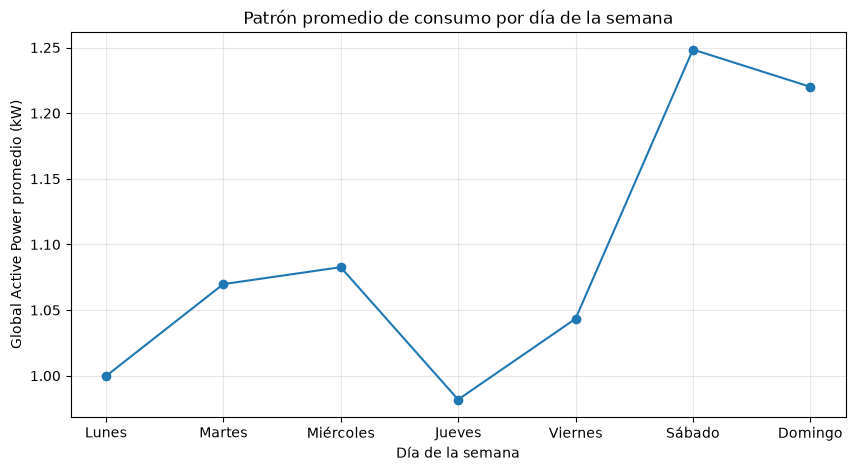

In [12]:
# Visualización del patrón promedio de consumo por día de la semana
plt.figure(figsize=(10, 5))

plt.plot(
    weekly_pattern.index,
    weekly_pattern["mean"],
    marker="o"
)

plt.title("Patrón promedio de consumo por día de la semana")
plt.xlabel("Día de la semana")
plt.ylabel("Global Active Power promedio (kW)")
plt.grid(alpha=0.3)

plt.show()

#### Interpretación del patrón por día de la semana

El consumo eléctrico presenta diferencias según el día de la semana. De lunes a viernes los valores promedio se mantienen relativamente cercanos, aproximadamente entre 0.98 y 1.08 kW, siendo el jueves el día con el menor consumo promedio.
El cambio más importante aparece durante el fin de semana. El sábado registra el mayor consumo promedio, con aproximadamente 1.25 kW, seguido del domingo con aproximadamente 1.22 kW. Ambos valores son superiores a los observados durante los días laborales, lo que aporta evidencia de un patrón semanal asociado al comportamiento del hogar. La cantidad de observaciones disponible para cada día es similar, por lo que las diferencias observadas no parecen estar explicadas por un desequilibrio importante en el número de registros. Además, las diferencias entre media y mediana muestran que la distribución del consumo continúa siendo asimétrica dentro de los distintos días de la semana.

**Decisión técnica:** el día de la semana contiene información potencialmente relevante para el pronóstico. Durante Feature Engineering se considerará incorporar esta información temporal y evaluar una característica adicional que permita distinguir entre días laborales y fines de semana (`is_weekend`). Estas características deberán evaluarse posteriormente durante el modelado para comprobar si mejoran el desempeño predictivo.

### 5.3 Patrón de consumo por mes

Se analiza el comportamiento de `Global_active_power` según el mes del año para determinar si existen variaciones sistemáticas del consumo a lo largo del ciclo anual.

Este análisis permite comprobar si los indicios observados previamente en la evolución temporal se reflejan también al agrupar las observaciones por mes. La existencia de diferencias mensuales podría aportar evidencia de estacionalidad anual y justificar posteriormente la incorporación de características relacionadas con el mes durante la etapa de Feature Engineering.

In [13]:
# Consumo por mes del año
monthly_pattern = (
    temporal_analysis
    .groupby("month")["Global_active_power"]
    .agg(["mean", "median", "std", "count"])
)

# Nombres de los meses para facilitar la interpretación
month_names = {
    1: "Enero",
    2: "Febrero",
    3: "Marzo",
    4: "Abril",
    5: "Mayo",
    6: "Junio",
    7: "Julio",
    8: "Agosto",
    9: "Septiembre",
    10: "Octubre",
    11: "Noviembre",
    12: "Diciembre"
}

monthly_pattern.index = monthly_pattern.index.map(month_names)

monthly_pattern

,mean,median,std,count
month,,,,
Enero,1.462296,1.372,1.222797,175431
Febrero,1.300329,1.262,1.164354,162720
Marzo,1.231374,0.940,1.102600,176533
Abril,1.047136,0.534,0.977319,169077
Mayo,1.029572,0.590,0.939278,178560
Junio,0.909223,0.464,0.894613,169495
Julio,0.700336,0.354,0.732078,178477
Agosto,0.572887,0.262,0.721997,170443
Septiembre,0.975709,0.516,0.953312,167563


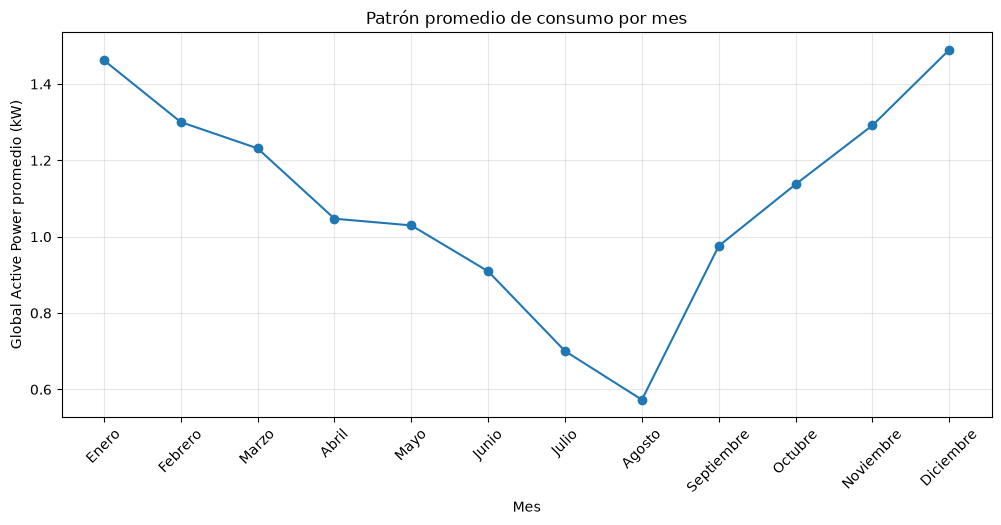

In [14]:
# Visualización del patrón promedio de consumo por mes
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_pattern.index,
    monthly_pattern["mean"],
    marker="o"
)

plt.title("Patrón promedio de consumo por mes")
plt.xlabel("Mes")
plt.ylabel("Global Active Power promedio (kW)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.show()

In [15]:
# Consumo promedio mensual separado por año
monthly_by_year = (
    df["Global_active_power"]
    .groupby([df.index.year, df.index.month])
    .mean()
    .unstack()
)

monthly_by_year.columns = [
    "Enero", "Febrero", "Marzo", "Abril",
    "Mayo", "Junio", "Julio", "Agosto",
    "Septiembre", "Octubre", "Noviembre", "Diciembre"
]

monthly_by_year.round(3)

,Enero,Febrero,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre
datetime,,,,,,,,,,,,
2006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.902
2007,1.546,1.401,1.319,0.891,0.986,0.827,0.667,0.764,0.969,1.104,1.294,1.626
2008,1.460,1.181,1.245,1.116,1.024,0.994,0.795,0.277,0.988,1.137,1.387,1.275
2009,1.410,1.247,1.227,1.141,1.013,0.841,0.618,0.665,0.987,1.144,1.275,1.364
2010,1.431,1.376,1.130,1.027,1.095,0.970,0.721,0.591,0.956,1.163,1.197,NaN


In [16]:
# Cantidad de observaciones válidas por mes y año
monthly_count_by_year = (
    df["Global_active_power"]
    .groupby([df.index.year, df.index.month])
    .count()
    .unstack()
)

monthly_count_by_year.columns = [
    "Enero", "Febrero", "Marzo", "Abril",
    "Mayo", "Junio", "Julio", "Agosto",
    "Septiembre", "Octubre", "Noviembre", "Diciembre"
]

monthly_count_by_year.loc[:, ["Julio", "Agosto", "Septiembre"]]

,Julio,Agosto,Septiembre
datetime,,,
2006,NaN,NaN,NaN
2007,44557.0,44640.0,43200.0
2008,44640.0,44640.0,43200.0
2009,44640.0,43749.0,43200.0
2010,44640.0,37414.0,37963.0


#### Interpretación del patrón mensual

El consumo eléctrico presenta diferencias importantes a lo largo de los meses del año. Los mayores niveles promedio se observan en diciembre y enero, con aproximadamente 1.49 kW y 1.46 kW respectivamente. A partir de estos meses el consumo disminuye progresivamente hasta alcanzar sus niveles más bajos durante julio y agosto, para posteriormente aumentar nuevamente entre septiembre y diciembre. Este comportamiento aporta evidencia exploratoria de un posible patrón estacional anual. Sin embargo, se identificó una caída especialmente pronunciada durante agosto, por lo que se realizó una revisión adicional separando los promedios mensuales por año. La comparación mostró que agosto presenta consumos relativamente bajos en varios años, pero agosto de 2008 destaca con un promedio aproximado de 0.277 kW, considerablemente inferior a los demás. Se verificó que este resultado no se debe a falta de información, ya que agosto de 2008 contiene las 44,640 observaciones correspondientes a un mes completo de 31 días con frecuencia de un minuto. Por lo tanto, no existe evidencia suficiente para considerar este período como un error o eliminarlo del dataset.

**Decisión técnica:** se conservarán todas las observaciones y el mes será considerado como una característica temporal potencialmente relevante durante Feature Engineering. La evidencia encontrada sugiere un posible componente estacional anual, pero esta conclusión deberá comprobarse posteriormente mediante el análisis específico de tendencia, estacionalidad y autocorrelación. El comportamiento atípicamente bajo de agosto de 2008 también deberá tenerse en cuenta durante la evaluación temporal del modelo.

## 6. Tendencia, estacionalidad y autocorrelación

Una vez identificados los patrones horarios, semanales y mensuales, se analiza la estructura temporal de la serie con mayor profundidad. El objetivo es determinar si el consumo presenta tendencia, componentes estacionales y dependencia respecto a sus valores pasados. Estos elementos son especialmente relevantes en un problema de pronóstico, ya que permiten comprender qué información temporal debería conservarse y posteriormente utilizarse durante la ingeniería de características y el entrenamiento del modelo.

### 6.1 Análisis de tendencia

Para estudiar la evolución de largo plazo del consumo se utilizará la serie agregada a frecuencia diaria. La agregación permite reducir las fluctuaciones presentes en los datos por minuto y facilita la identificación de movimientos persistentes en el nivel de consumo. Sobre esta serie se calculará una media móvil de 30 días como herramienta exploratoria para suavizar las variaciones de corto plazo y observar con mayor claridad posibles cambios en el comportamiento general de la serie.

In [17]:
# Serie diaria de potencia activa
daily_series = (
    df["Global_active_power"]
    .resample("D")
    .mean()
)

# Media móvil de 30 días
rolling_mean_30d = daily_series.rolling(
    window=30,
    min_periods=15
).mean()

print(f"Días totales: {len(daily_series):,}")
print(f"Días con información: {daily_series.notna().sum():,}")
print(f"Días sin información: {daily_series.isna().sum():,}")

Días totales: 1,442
Días con información: 1,433
Días sin información: 9


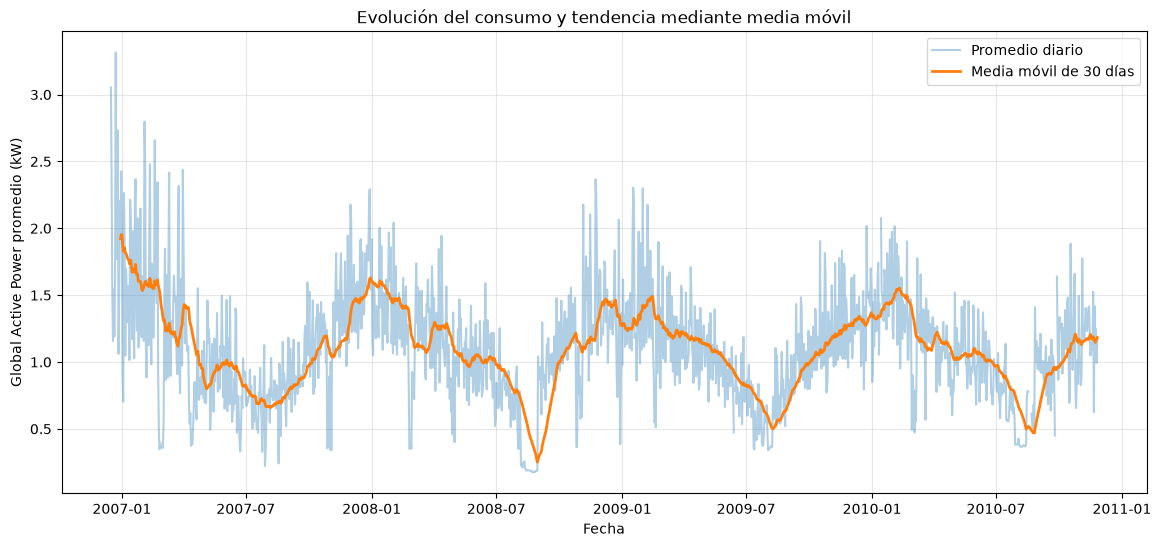

In [19]:
# Visualización de la serie diaria y su media móvil
plt.figure(figsize=(14, 6))

plt.plot(
    daily_series.index,
    daily_series,
    alpha=0.35,
    label="Promedio diario"
)

plt.plot(
    rolling_mean_30d.index,
    rolling_mean_30d,
    linewidth=2,
    label="Media móvil de 30 días"
)

plt.title("Evolución del consumo y tendencia mediante media móvil")
plt.xlabel("Fecha")
plt.ylabel("Global Active Power promedio (kW)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

#### Interpretación de la tendencia

La media móvil de 30 días permite observar con mayor claridad la evolución general del consumo al reducir las fluctuaciones presentes en los valores diarios. No se identifica una tendencia global sostenida de crecimiento o disminución durante todo el período analizado. En su lugar, el nivel de consumo presenta oscilaciones recurrentes a lo largo de los años. Se observa que el consumo tiende a alcanzar niveles relativamente altos alrededor del cierre e inicio de algunos años y posteriormente disminuye hacia períodos intermedios del año. Este comportamiento es consistente con el patrón mensual identificado anteriormente y aporta nueva evidencia de que una parte importante de la variación de la serie podría estar asociada a un componente estacional y no a una tendencia lineal de largo plazo.

También destaca una disminución especialmente pronunciada alrededor de agosto de 2008. Este período ya fue revisado durante el análisis mensual y se comprobó que cuenta con las observaciones esperadas, por lo que se conserva como un comportamiento real presente en el dataset y no se elimina como error.Los 9 días completamente sin información permanecen visibles como parte de la estructura temporal original y no se reconstruyen artificialmente, manteniendo la decisión adoptada durante la etapa de limpieza.

**Decisión técnica:** no se asumirá una tendencia lineal creciente o decreciente como característica principal de la serie. Las oscilaciones recurrentes observadas justifican continuar con un análisis específico de estacionalidad. La media móvil se utiliza únicamente como herramienta exploratoria y no implica todavía una transformación definitiva de los datos para el modelado.

### 6.2 Análisis de estacionalidad

Los análisis anteriores mostraron variaciones recurrentes del consumo según la hora del día, el día de la semana y el mes del año. Además, la media móvil de 30 días mostró oscilaciones que parecen repetirse aproximadamente a lo largo de los años. Para estudiar de manera más específica el posible componente estacional anual, se realizará una descomposición de la serie diaria. Debido a que existen días completamente sin información y la descomposición requiere una serie continua, se utilizará únicamente para este análisis una versión auxiliar interpolada de la serie diaria. Esta interpolación no modifica el dataset limpio ni implica que los valores faltantes sean imputados para el posterior modelado. Se utilizará un período de 365 días para representar exploratoriamente un ciclo anual.

In [21]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Serie auxiliar exclusivamente para la descomposición
daily_for_decomposition = daily_series.interpolate(
    method="time",
    limit_direction="both"
)

decomposition = seasonal_decompose(
    daily_for_decomposition,
    model="additive",
    period=365,
    extrapolate_trend="freq"
)

print(f"Observaciones utilizadas: {len(daily_for_decomposition):,}")
print(f"Valores faltantes después de interpolación auxiliar: "
      f"{daily_for_decomposition.isna().sum()}")

Observaciones utilizadas: 1,442
Valores faltantes después de interpolación auxiliar: 0


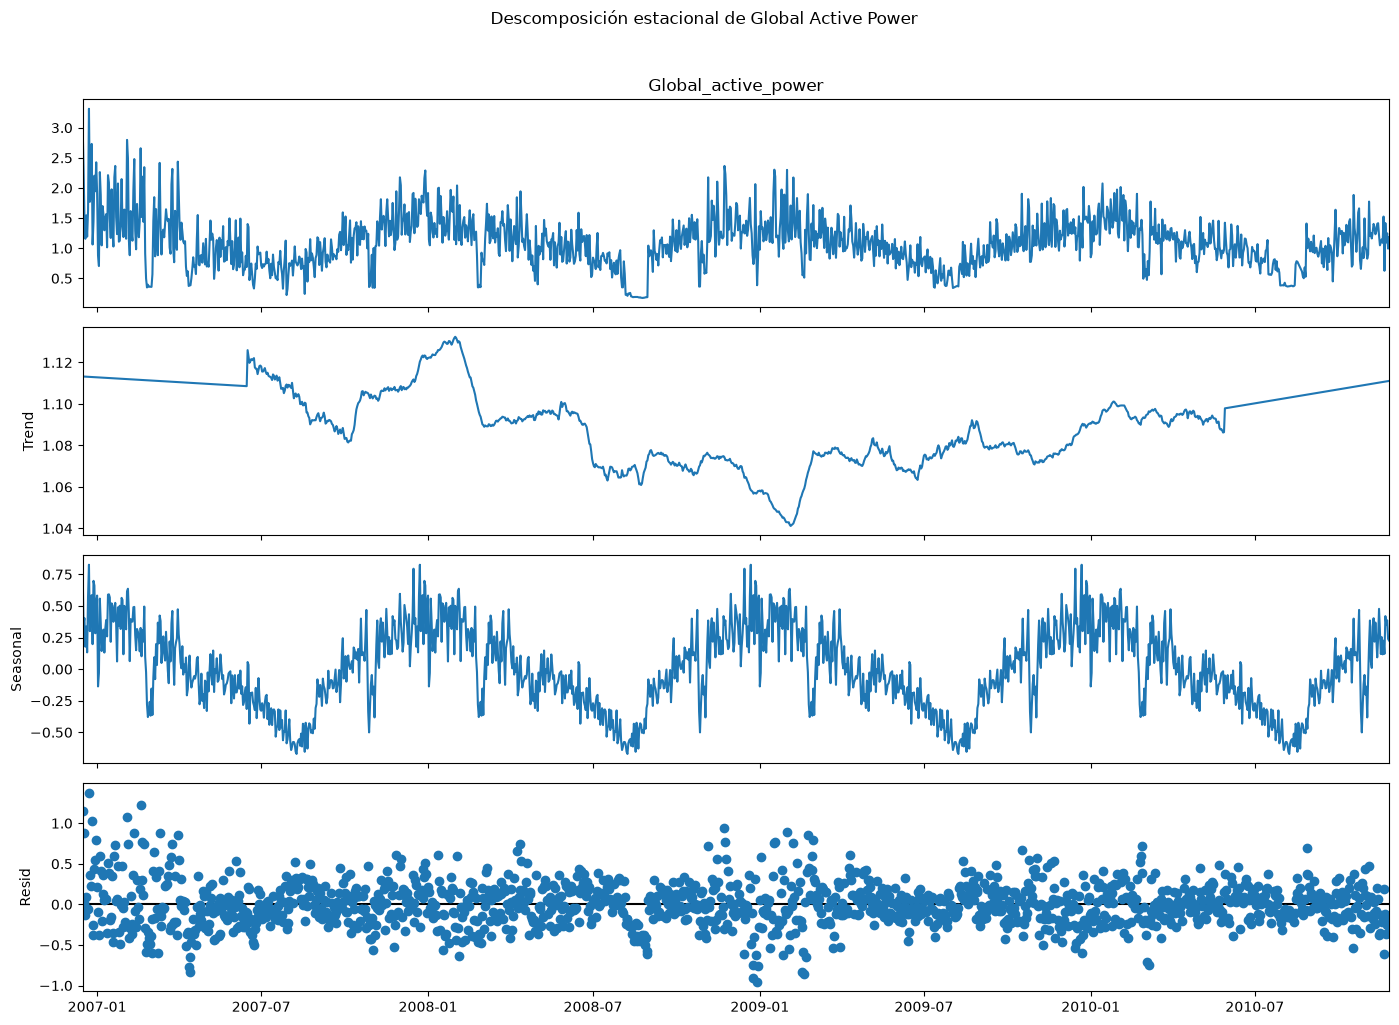

In [22]:
# Visualización de la descomposición estacional
fig = decomposition.plot()

fig.set_size_inches(14, 10)
fig.suptitle(
    "Descomposición estacional de Global Active Power",
    y=1.02
)

plt.tight_layout()
plt.show()

#### Interpretación de la estacionalidad anual

La descomposición de la serie diaria permite separar el comportamiento observado en componentes de tendencia, estacionalidad y residuo. El componente estacional presenta un patrón claramente recurrente con un ciclo aproximado de un año, lo que respalda la evidencia obtenida previamente mediante el análisis mensual del consumo. El patrón estacional muestra períodos con una contribución positiva al consumo hacia el cierre e inicio del año y una disminución progresiva hacia los meses intermedios, alcanzando sus niveles más bajos aproximadamente durante el período de mitad de año. Posteriormente, el componente vuelve a incrementarse. La repetición de esta estructura a lo largo de los años indica que el momento del año contiene información relevante para explicar el comportamiento del consumo eléctrico.

El componente de tendencia, por su parte, presenta variaciones de largo plazo, pero no evidencia un crecimiento o disminución sostenidos durante todo el período. Esto refuerza la conclusión anterior de que una parte importante de las variaciones observadas corresponde a comportamiento estacional y no únicamente a una tendencia general. Finalmente, el componente residual conserva variaciones y algunos valores extremos que no son explicados completamente por la tendencia ni por el ciclo estacional anual. Estos comportamientos deberán considerarse posteriormente durante el análisis de valores atípicos.

**Decisión técnica:** la estacionalidad anual se considera una característica relevante de la serie y deberá ser tomada en cuenta durante la ingeniería de características y la selección del enfoque de pronóstico. Variables temporales como mes, época del año y otras representaciones estacionales podrán ser evaluadas posteriormente. La interpolación realizada para esta descomposición fue exclusivamente auxiliar y no modifica la decisión de conservar los gaps originales en los datos utilizados para modelado.

### 6.3 Análisis de autocorrelación

En un problema de pronóstico es importante determinar si los valores actuales del consumo mantienen relación con observaciones anteriores. Si existe autocorrelación, los valores pasados pueden aportar información relevante para predecir el consumo futuro y posteriormente podrían utilizarse mediante variables rezagadas (lags). Para este análisis se utilizará una serie agregada a frecuencia horaria. Esta frecuencia permite reducir la granularidad de los datos originales por minuto y estudiar de forma interpretable dependencias temporales asociadas a ciclos como 24 horas y una semana (168 horas).

La utilización de frecuencia horaria en este análisis es exploratoria y todavía no establece de manera definitiva la frecuencia que será utilizada durante el entrenamiento.

In [23]:
# Serie horaria auxiliar para análisis de autocorrelación
hourly_series = (
    df["Global_active_power"]
    .resample("h")
    .mean()
)

print(f"Horas analizadas: {len(hourly_series):,}")
print(f"Horas con información: {hourly_series.notna().sum():,}")
print(f"Horas sin información: {hourly_series.isna().sum():,}")

Horas analizadas: 34,589
Horas con información: 34,168
Horas sin información: 421


In [24]:
# Serie auxiliar para el análisis de autocorrelación
hourly_for_acf = hourly_series.interpolate(
    method="time",
    limit_direction="both"
)

print(f"Valores faltantes originales: {hourly_series.isna().sum():,}")
print(f"Valores faltantes en serie auxiliar: {hourly_for_acf.isna().sum():,}")

Valores faltantes originales: 421
Valores faltantes en serie auxiliar: 0


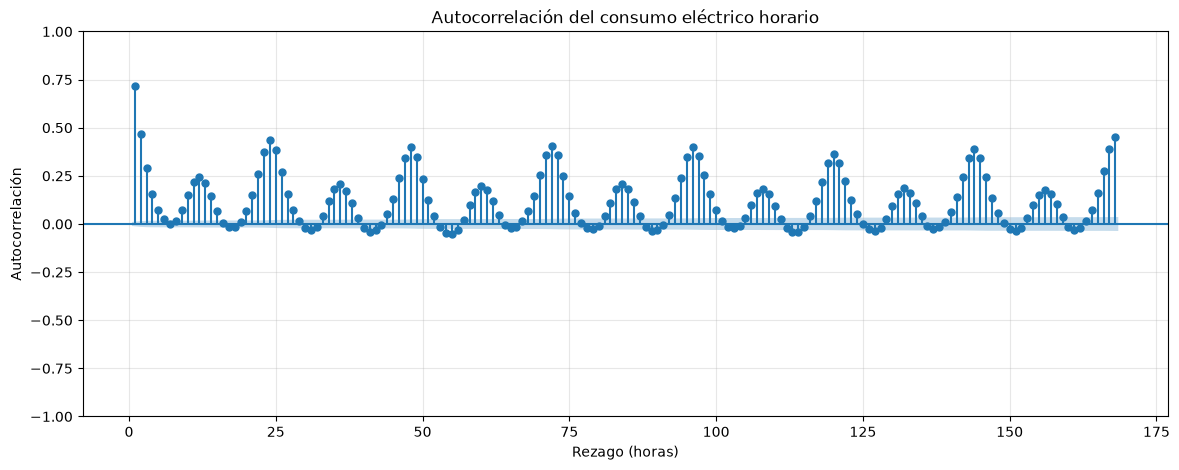

In [25]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(14, 5))

plot_acf(
    hourly_for_acf,
    lags=168,
    ax=ax,
    zero=False
)

ax.set_title("Autocorrelación del consumo eléctrico horario")
ax.set_xlabel("Rezago (horas)")
ax.set_ylabel("Autocorrelación")
ax.grid(alpha=0.3)

plt.show()

#### Interpretación de la autocorrelación

La función de autocorrelación muestra una dependencia temporal importante en el consumo eléctrico. El primer rezago presenta una autocorrelación elevada, lo que indica que el consumo de una hora mantiene una relación considerable con el consumo observado en la hora inmediatamente anterior. Además de esta dependencia de corto plazo, se observa un patrón periódico de incrementos en la autocorrelación aproximadamente cada 24 horas. Este comportamiento se mantiene a lo largo de la semana analizada, con nuevos incrementos alrededor de los rezagos 24, 48, 72, 96, 120, 144 y 168 horas. Esto aporta evidencia adicional de un ciclo diario en el consumo eléctrico y es consistente con el patrón por hora del día identificado previamente.La presencia de autocorrelación incluso en rezagos alejados indica que las observaciones de la serie no son independientes y que los valores históricos contienen información potencialmente útil para pronosticar valores futuros. Las 421 horas sin información fueron interpoladas únicamente en una serie auxiliar para permitir este diagnóstico. Esta operación no modifica el dataset limpio ni establece todavía una estrategia definitiva para el tratamiento de gaps durante el entrenamiento.

**Decisión técnica:** la ingeniería de características deberá evaluar variables rezagadas que representen tanto dependencia reciente como ciclos temporales, incluyendo candidatos asociados a períodos de 1 hora, 24 horas y 168 horas. Estos rezagos no se incorporarán automáticamente al modelo; su utilidad deberá evaluarse posteriormente evitando cualquier fuga de información temporal.

## 7. Outliers, gaps y relaciones entre variables

Después de estudiar la estructura temporal del consumo, se analizarán los valores extremos, los gaps temporales y las relaciones existentes entre las variables eléctricas. En una serie temporal de consumo eléctrico, un valor estadísticamente extremo no necesariamente representa un error. Los picos pueden corresponder a eventos reales de alto consumo y contener información relevante para el pronóstico. Por esta razón, los valores extremos serán identificados y posteriormente evaluados considerando su contexto temporal antes de tomar cualquier decisión sobre su tratamiento. También se estudiará la distribución temporal de los períodos sin información y las relaciones entre las variables eléctricas disponibles.

### 7.1 Identificación de valores extremos

Como primera aproximación se utilizará el rango intercuartílico (IQR) sobre `Global_active_power` para identificar observaciones estadísticamente alejadas de la distribución central. Este criterio se utiliza únicamente como herramienta exploratoria. Las observaciones detectadas no serán eliminadas automáticamente, ya que la asimetría previamente identificada en el consumo y la naturaleza temporal de los datos pueden producir valores elevados completamente válidos.

In [26]:
# Límites exploratorios mediante el criterio IQR
q1 = df["Global_active_power"].quantile(0.25)
q3 = df["Global_active_power"].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

extreme_values = df[
    (df["Global_active_power"] < lower_bound) |
    (df["Global_active_power"] > upper_bound)
]["Global_active_power"]

print(f"Q1: {q1:.3f} kW")
print(f"Q3: {q3:.3f} kW")
print(f"IQR: {iqr:.3f} kW")
print(f"Límite inferior: {lower_bound:.3f} kW")
print(f"Límite superior: {upper_bound:.3f} kW")
print(f"Valores identificados por IQR: {len(extreme_values):,}")
print(
    f"Porcentaje sobre observaciones válidas: "
    f"{len(extreme_values) / df['Global_active_power'].notna().sum() * 100:.2f}%"
)

Q1: 0.308 kW
Q3: 1.528 kW
IQR: 1.220 kW
Límite inferior: -1.522 kW
Límite superior: 3.358 kW
Valores identificados por IQR: 94,925
Porcentaje sobre observaciones válidas: 4.63%


#### Contexto temporal de los valores extremos

El criterio IQR identificó 94,925 observaciones como estadísticamente extremas, equivalentes al 4.63 % de las observaciones válidas de `Global_active_power`. El límite inferior calculado es negativo, por lo que los valores detectados corresponden esencialmente a observaciones de consumo elevado por encima de 3.358 kW. Dado que se trata de una proporción considerable del dataset y que la distribución del consumo presenta asimetría positiva, estos valores no se interpretan automáticamente como errores. A continuación se analizará su distribución temporal para determinar si aparecen asociados a períodos específicos de consumo.

In [27]:
# Identificación temporal de observaciones por encima del límite IQR
high_consumption = df.loc[
    df["Global_active_power"] > upper_bound,
    ["Global_active_power"]
].copy()

high_consumption["year"] = high_consumption.index.year
high_consumption["hour"] = high_consumption.index.hour

# Cantidad de valores extremos por año
extremes_by_year = high_consumption.groupby("year").size()

# Cantidad de valores extremos por hora del día
extremes_by_hour = high_consumption.groupby("hour").size()

print("Valores extremos por año:")
display(extremes_by_year.to_frame(name="count"))

print("\nValores extremos por hora del día:")
display(extremes_by_hour.to_frame(name="count"))

Valores extremos por año:


,count
year,
2006,3641
2007,32101
2008,24766
2009,20372
2010,14045



Valores extremos por hora del día:


,count
hour,
0,1147
1,593
2,239
3,82
4,80
5,103
6,2339
7,4556
8,4651


#### Interpretación de los valores extremos

El criterio IQR identificó 94,925 observaciones de `Global_active_power` por encima del límite superior de 3.358 kW, equivalentes al 4.63 % de las observaciones válidas. Sin embargo, su distribución temporal muestra que una parte importante de estos valores es consistente con los patrones habituales de consumo identificados previamente. Los valores extremos presentan una clara concentración según la hora del día. Durante la madrugada su frecuencia es reducida, mientras que aumenta durante las horas de mayor actividad. La mayor concentración ocurre entre las 19:00 y 21:00 horas, alcanzando su máximo a las 20:00. Este comportamiento coincide con el patrón intradiario previamente identificado, donde el consumo promedio también alcanza sus niveles más altos durante la noche.

Los valores extremos también aparecen distribuidos a lo largo de todos los años analizados. Los menores conteos de 2006 y 2010 deben interpretarse considerando que ambos corresponden a años incompletos dentro del período disponible. Por lo tanto, el criterio IQR está identificando como valores estadísticamente extremos numerosas observaciones que pueden corresponder a episodios reales de alto consumo y no necesariamente a errores o anomalías.

**Decisión técnica:** no se eliminarán ni limitarán automáticamente las observaciones identificadas mediante IQR. Los picos de consumo se conservarán, ya que contienen información potencialmente relevante para el pronóstico. El criterio IQR se mantiene únicamente como herramienta descriptiva para identificar valores extremos.

### 7.2 Análisis de gaps temporales

La cantidad total de valores faltantes no permite conocer por sí sola la estructura de las interrupciones presentes en la serie. En un problema de pronóstico es importante distinguir entre observaciones faltantes aisladas y períodos consecutivos sin información, ya que su tratamiento puede requerir estrategias diferentes. Para estudiar esta estructura se analizarán los gaps sobre la serie horaria. Esta frecuencia permite identificar interrupciones relevantes para el posible modelado sin trabajar directamente con cada observación por minuto.

El objetivo de este análisis no es imputar los valores faltantes, sino determinar cuántos bloques de ausencia existen, cuánto duran y cuál es la interrupción más extensa.

In [28]:
# Identificación de horas completamente sin información
missing_hours = hourly_series.isna()

# Identificamos bloques consecutivos
gap_groups = missing_hours.ne(missing_hours.shift()).cumsum()

# Duración de cada bloque compuesto únicamente por valores faltantes
hourly_gaps = (
    missing_hours[missing_hours]
    .groupby(gap_groups[missing_hours])
    .size()
)

print(f"Horas completamente sin información: {missing_hours.sum():,}")
print(f"Número de gaps horarios: {len(hourly_gaps):,}")

if len(hourly_gaps) > 0:
    print(f"Gap mínimo: {hourly_gaps.min():,} hora(s)")
    print(f"Gap mediano: {hourly_gaps.median():.1f} hora(s)")
    print(f"Gap promedio: {hourly_gaps.mean():.2f} hora(s)")
    print(f"Gap máximo: {hourly_gaps.max():,} hora(s)")

Horas completamente sin información: 421
Número de gaps horarios: 8
Gap mínimo: 1 hora(s)
Gap mediano: 53.0 hora(s)
Gap promedio: 52.62 hora(s)
Gap máximo: 119 hora(s)


In [29]:
# Distribución de los gaps según su duración
gap_summary = pd.Series({
    "1 hora": (hourly_gaps == 1).sum(),
    "2-3 horas": hourly_gaps.between(2, 3).sum(),
    "4-6 horas": hourly_gaps.between(4, 6).sum(),
    "7-12 horas": hourly_gaps.between(7, 12).sum(),
    "13-24 horas": hourly_gaps.between(13, 24).sum(),
    "Más de 24 horas": (hourly_gaps > 24).sum()
})

gap_summary.to_frame(name="Número de gaps")

,Número de gaps
1 hora,1
2-3 horas,0
4-6 horas,0
7-12 horas,0
13-24 horas,1
Más de 24 horas,6


In [30]:
# Identificación de inicio, fin y duración de cada gap horario
gap_details = []

for group_id, group in hourly_series[missing_hours].groupby(
    gap_groups[missing_hours]
):
    gap_details.append({
        "inicio": group.index.min(),
        "fin": group.index.max(),
        "duracion_horas": len(group)
    })

gap_details = (
    pd.DataFrame(gap_details)
    .sort_values("inicio")
    .reset_index(drop=True)
)

gap_details

,inicio,fin,duracion_horas
0,2007-04-28 01:00:00,2007-04-30 13:00:00,61
1,2007-07-15 17:00:00,2007-07-15 17:00:00,1
2,2009-06-13 01:00:00,2009-06-15 06:00:00,54
3,2009-08-13 05:00:00,2009-08-13 18:00:00,14
4,2010-01-12 15:00:00,2010-01-14 18:00:00,52
5,2010-03-20 04:00:00,2010-03-21 12:00:00,33
6,2010-08-17 22:00:00,2010-08-22 20:00:00,119
7,2010-09-25 04:00:00,2010-09-28 18:00:00,87


#### Interpretación de los gaps temporales

El análisis de la serie horaria muestra que las 421 horas completamente sin información no corresponden principalmente a pérdidas aisladas, sino que se concentran en únicamente 8 interrupciones temporales. De estos gaps, solo uno tiene una duración de una hora, mientras que los siete restantes presentan duraciones de 14 horas o más. Las interrupciones más extensas alcanzan 119 y 87 horas consecutivas, equivalentes aproximadamente a cinco y tres días y medio de información ausente, respectivamente. Además, los gaps aparecen en diferentes momentos del período analizado, por lo que no se observa una única interrupción concentrada en una sola zona de la serie. Este resultado es especialmente relevante para el posterior modelado, ya que la autocorrelación mostró un patrón diario importante de 24 horas. La interpolación automática de gaps que abarcan varios ciclos diarios podría introducir patrones artificiales de consumo y reducir artificialmente la variabilidad de la serie.

**Decisión técnica:** los gaps largos se conservarán sin imputar en el dataset limpio. No se aplicará una interpolación general sobre la serie, ya que la mayoría de las interrupciones abarcan períodos suficientemente extensos como para que su reconstrucción implique asumir comportamiento no observado. Las interpolaciones realizadas anteriormente para la descomposición estacional y la autocorrelación fueron exclusivamente auxiliares y no modifican el dataset original. El tratamiento definitivo de los faltantes se determinará posteriormente de acuerdo con la frecuencia seleccionada y los requerimientos del modelo de pronóstico.

### 7.3 Relaciones entre variables

Además del comportamiento temporal de la serie objetivo, es necesario analizar la relación entre las distintas mediciones eléctricas disponibles en el dataset. Este análisis permite identificar variables fuertemente asociadas con `Global_active_power`, posibles redundancias y características que podrían aportar información al posterior modelo de pronóstico. Como primera aproximación se calculará la matriz de correlación de Pearson entre las variables numéricas. La correlación se utilizará como herramienta exploratoria para medir relaciones lineales, sin interpretarla como evidencia de causalidad.

In [31]:
# Matriz de correlación entre las variables eléctricas
correlation_matrix = df.corr(method="pearson")

# Correlaciones específicamente con la variable objetivo
target_correlations = (
    correlation_matrix["Global_active_power"]
    .drop("Global_active_power")
    .sort_values(ascending=False)
)

target_correlations.to_frame(
    name="correlation_with_Global_active_power"
).round(3)

,correlation_with_Global_active_power
Global_intensity,0.999
Sub_metering_3,0.639
Sub_metering_1,0.484
Sub_metering_2,0.435
Global_reactive_power,0.247
Voltage,-0.400


#### Matriz de correlación

Las correlaciones con la variable objetivo muestran una asociación lineal especialmente elevada entre `Global_active_power` y `Global_intensity`, mientras que los submedidores presentan asociaciones positivas de diferente magnitud. Para complementar este análisis se visualizará la matriz de correlación completa, con el objetivo de identificar también posibles relaciones fuertes entre las variables explicativas.

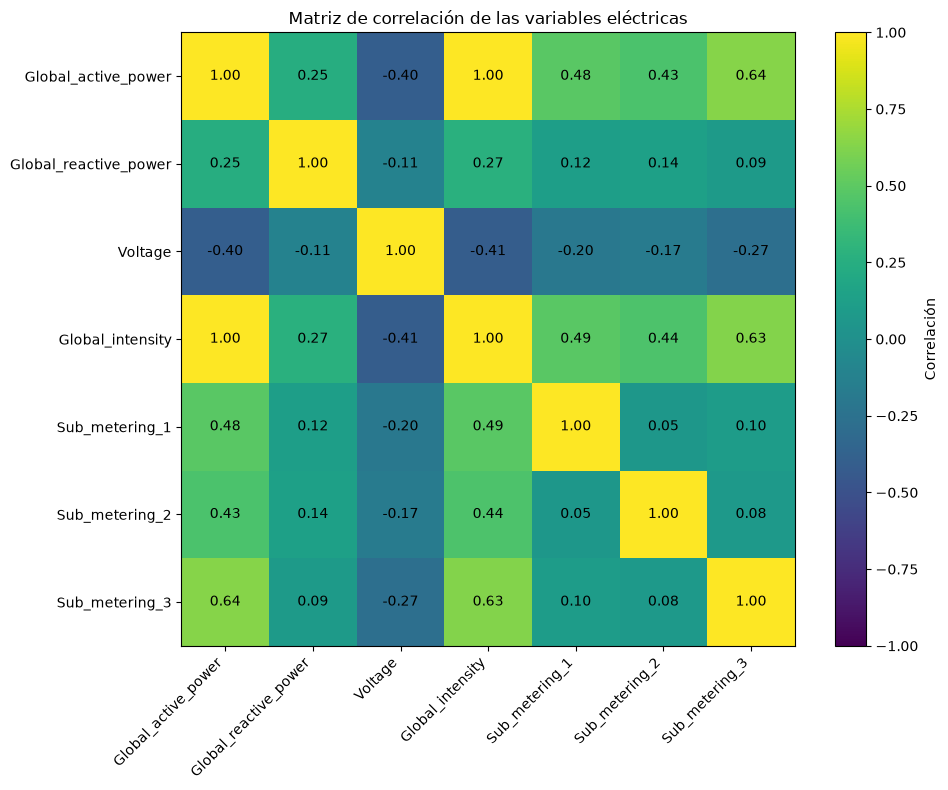

In [33]:
# Visualización de la matriz de correlación
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    correlation_matrix,
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_yticks(range(len(correlation_matrix.columns)))

ax.set_xticklabels(
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(correlation_matrix.columns)

# Valores de correlación dentro de cada celda
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        ax.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

fig.colorbar(im, ax=ax, label="Correlación")

ax.set_title("Matriz de correlación de las variables eléctricas")

plt.tight_layout()
plt.show()

#### Interpretación de las relaciones entre variables

La matriz de correlación muestra una asociación lineal prácticamente perfecta entre `Global_active_power` y `Global_intensity`, con una correlación de aproximadamente 0.999. Esto indica que ambas variables contienen información muy similar sobre el nivel de consumo eléctrico. Esta relación deberá considerarse posteriormente durante la selección de características, especialmente para evitar incorporar variables redundantes o información que no estaría disponible en el momento de realizar un pronóstico. Los tres submedidores presentan relaciones positivas con la potencia activa global, aunque con diferente intensidad. `Sub_metering_3` presenta la asociación más elevada (0.639), seguido de `Sub_metering_1` (0.484) y `Sub_metering_2` (0.435). Al mismo tiempo, las correlaciones entre los propios submedidores son bajas, lo que indica que representan componentes diferentes del consumo y podrían aportar información complementaria.`Global_reactive_power` presenta una asociación positiva débil con la variable objetivo (0.247), mientras que `Voltage` muestra una relación negativa moderada (-0.400). Por lo tanto, una correlación baja o negativa no será utilizada por sí sola como criterio para descartar variables.

**Decisión técnica:** no se eliminarán variables durante esta etapa exploratoria únicamente a partir de sus correlaciones. La fuerte relación entre `Global_active_power` y `Global_intensity` queda documentada como una posible fuente de redundancia que deberá evaluarse durante la ingeniería y selección de características. Para el posterior pronóstico también será necesario garantizar que cualquier variable utilizada como predictor esté disponible en el momento real de realizar la predicción y no introduzca información futura.

## 8. Conclusiones del EDA y decisiones para el modelado

El análisis exploratorio permitió caracterizar tanto la distribución como la estructura temporal del consumo eléctrico y obtener evidencia para orientar las siguientes etapas del proyecto.

### Principales hallazgos y decisiones

| Hallazgo | Evidencia encontrada | Decisión técnica |
|---|---|---|
| Distribución asimétrica del consumo | `Global_active_power` presenta media superior a la mediana y asimetría positiva. | No asumir normalidad ni eliminar valores elevados únicamente por su distancia respecto a la media. |
| Patrón intradiario | El consumo disminuye durante la madrugada, aumenta alrededor de las 7:00–8:00 y alcanza su mayor nivel aproximadamente entre las 19:00–21:00. | La hora del día puede ser una característica temporal relevante para el modelo. |
| Patrón semanal | El consumo promedio aumenta durante el fin de semana, especialmente sábado y domingo. | Considerar día de la semana y/o indicador de fin de semana como posibles características. |
| Patrón anual | El consumo es mayor durante los meses cercanos al inicio y final del año y menor durante los meses centrales. | Existe evidencia para incorporar información estacional del calendario. |
| Tendencia no constante | La media móvil muestra cambios graduales en el nivel de consumo a lo largo del período analizado. | El orden temporal debe preservarse y la evaluación del modelo no deberá realizar divisiones aleatorias de la serie. |
| Estacionalidad | La descomposición de la serie diaria muestra un componente estacional recurrente aproximadamente anual. | Considerar estacionalidad de largo plazo durante la ingeniería de características y selección del modelo. |
| Autocorrelación | La serie horaria presenta dependencia temporal y picos recurrentes aproximadamente cada 24 horas y sus múltiplos. | Los rezagos de consumo, especialmente los asociados con ciclos diarios, son candidatos para la ingeniería de características. |
| Valores extremos | El criterio IQR identifica 94,925 observaciones (4.63 %), concentradas principalmente durante períodos habituales de mayor consumo. | Conservar los valores extremos y no eliminarlos automáticamente, ya que pueden representar episodios reales de consumo. |
| Gaps temporales | Se identificaron 421 horas completamente vacías agrupadas en solo 8 gaps; 6 superan las 24 horas y el máximo alcanza 119 horas. | No realizar interpolación general de los gaps largos. Su tratamiento dependerá de la frecuencia y del modelo seleccionado. |
| Relaciones entre variables | `Global_intensity` presenta una correlación aproximada de 0.999 con `Global_active_power`; los submedidores presentan asociaciones positivas de diferente magnitud. | Evaluar posteriormente redundancia, disponibilidad de variables al momento de inferencia y riesgo de utilizar información no disponible para el pronóstico. |

### Implicaciones para la siguiente etapa

Los resultados confirman que el problema debe tratarse respetando explícitamente la naturaleza temporal de los datos. La serie presenta patrones intradiarios, semanales y anuales, además de una dependencia significativa respecto a observaciones anteriores. La ingeniería de características deberá evaluar variables derivadas del calendario y rezagos del consumo, evitando utilizar información futura. Asimismo, la separación entre entrenamiento, validación y prueba deberá mantener el orden cronológico para representar correctamente un escenario real de pronóstico. La frecuencia definitiva de modelado todavía no se establece únicamente a partir del EDA. Tanto la frecuencia horaria como la diaria permiten representar patrones relevantes, pero implican diferentes niveles de granularidad, cantidad de observaciones y tratamiento de los gaps. La selección deberá realizarse considerando conjuntamente los resultados exploratorios y los requerimientos del modelo.

**Decisión general del EDA:** conservar el dataset limpio sin modificaciones adicionales derivadas exclusivamente del análisis exploratorio. Los resultados obtenidos se utilizarán como evidencia para definir posteriormente la frecuencia de modelado, estrategia de tratamiento de faltantes, ingeniería de características, división temporal de los datos y selección del enfoque de pronóstico.